##Tiny NeRF
This is a simplied version of the method presented in *NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis*

[Project Website](http://www.matthewtancik.com/nerf)

[arXiv Paper](https://arxiv.org/abs/2003.08934)

[Full Code](github.com/bmild/nerf)

Components not included in the notebook
*   5D input including view directions
*   Hierarchical Sampling



### **What is NeRF?**

This notebook demonstrates a simplified version of **Neural Radiance Fields (NeRF)**. Imagine you take several photos of a 3D object from different positions. NeRF tries to learn a continuous 3D representation of that object and the light it reflects. Once it learns this, you can ask it to generate a picture of the object from *any* viewpoint, even ones it hasn't seen before!

It does this by training a small neural network (a computer program inspired by the human brain) to predict the color and density of every point in 3D space. When you want to render a new image, it "shoots" rays from the camera through these points and uses the predicted colors and densities to calculate what the final pixel color should be.

In [1]:
!pip install tensorflow==2.15.0 keras==2.15.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [2]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

# Removed: %tensorflow_version 1.x as it's unsupported

import os, sys
import tensorflow as tf
# Removed: tf.compat.v1.enable_eager_execution() as it's TF1.x specific and not needed for TF2.x

from tqdm import tqdm_notebook as tqdm
import numpy as np
import matplotlib.pyplot as plt

### **Setting up the Environment**

This section sets up the necessary tools and libraries for the notebook.

*   `tensorflow` and `keras`: These are powerful libraries for building and training neural networks. We're installing specific versions to ensure compatibility.
*   `os`, `sys`, `numpy`, `matplotlib.pyplot`: These are standard Python libraries for interacting with the operating system, numerical operations, and plotting graphs/images.
*   `tqdm`: This library provides progress bars, which are very helpful when running long training loops, so you can see how much progress has been made.

In [3]:
if not os.path.exists('tiny_nerf_data.npz'):
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

--2026-06-23 08:32:16--  http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Resolving cseweb.ucsd.edu (cseweb.ucsd.edu)... 132.239.8.30
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz [following]
--2026-06-23 08:32:16--  https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12727482 (12M)
Saving to: ‘tiny_nerf_data.npz’

tiny_nerf_data.npz  100%[===================>]  12.14M  79.7MB/s    in 0.2s    

2026-06-23 08:32:17 (79.7 MB/s) - ‘tiny_nerf_data.npz’ saved [12727482/12727482]



# Load Input Images and Poses

(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


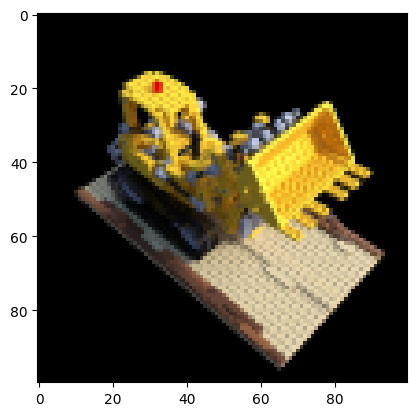

In [4]:
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]
print(images.shape, poses.shape, focal)

testimg, testpose = images[101], poses[101]
images = images[:100,...,:3]
poses = poses[:100]

plt.imshow(testimg)
plt.show()

### **Loading the Data**

Here, the notebook loads the dataset it will use to train the NeRF model. This dataset contains:

*   `images`: A collection of 2D images of a scene (in this case, a toy bulldozer).
*   `poses`: The exact 3D position and orientation (the "pose") of the camera when each image was taken. This is crucial because NeRF needs to know *where* each picture came from.
*   `focal`: The focal length of the camera, which is a property of the lens that tells us how wide or narrow the field of view is.
*   `H` and `W`: The height and width of the images in pixels.

The code then separates a `testimg` and `testpose` to evaluate the model's performance on an unseen view later. The `plt.imshow(testimg)` line simply displays one of these images so you can see what the model will be working with.

# Optimize NeRF

In [5]:
def posenc(x):
  rets = [x]
  for i in range(L_embed):
    for fn in [tf.sin, tf.cos]:
      rets.append(fn(2.**i * x))
  return tf.concat(rets, -1)

L_embed = 6
embed_fn = posenc
# L_embed = 0
# embed_fn = tf.identity

def init_model(D=8, W=256):
    relu = tf.keras.layers.ReLU()
    dense = lambda W=W, act=relu: tf.keras.layers.Dense(W, activation=act)

    inputs = tf.keras.Input(shape=(3 + 3*2*L_embed,))
    outputs = inputs

    for i in range(D):
        outputs = dense()(outputs)

        if i % 4 == 0 and i > 0:
            outputs = tf.keras.layers.Concatenate(axis=-1)([outputs, inputs])

    outputs = dense(4, act=None)(outputs)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


def get_rays(H, W, focal, c2w):
    i, j = tf.meshgrid(tf.range(W, dtype=tf.float32), tf.range(H, dtype=tf.float32), indexing='xy')
    dirs = tf.stack([(i-W*.5)/focal, -(j-H*.5)/focal, -tf.ones_like(i)], -1)
    rays_d = tf.reduce_sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)
    rays_o = tf.broadcast_to(c2w[:3,-1], tf.shape(rays_d))
    return rays_o, rays_d



def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):

    def batchify(fn, chunk=1024*32):
        return lambda inputs : tf.concat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)

    # Compute 3D query points
    z_vals = tf.linspace(near, far, N_samples)
    if rand:
      z_vals += tf.random.uniform(list(rays_o.shape[:-1]) + [N_samples]) * (far-near)/N_samples
    pts = rays_o[...,None,:] + rays_d[...,None,:] * z_vals[...,:,None]

    # Run network
    pts_flat = tf.reshape(pts, [-1,3])
    pts_flat = embed_fn(pts_flat)
    raw = batchify(network_fn)(pts_flat)
    raw = tf.reshape(raw, list(pts.shape[:-1]) + [4])

    # Compute opacities and colors
    sigma_a = tf.nn.relu(raw[...,3])
    rgb = tf.math.sigmoid(raw[...,:3])

    # Do volume rendering
    dists = tf.concat([z_vals[..., 1:] - z_vals[..., :-1], tf.broadcast_to([1e10], z_vals[...,:1].shape)], -1)
    alpha = 1.-tf.exp(-sigma_a * dists)
    weights = alpha * tf.math.cumprod(1.-alpha + 1e-10, -1, exclusive=True)

    rgb_map = tf.reduce_sum(weights[...,None] * rgb, -2)
    depth_map = tf.reduce_sum(weights * z_vals, -1)
    acc_map = tf.reduce_sum(weights, -1)

    return rgb_map, depth_map, acc_map

### **Core NeRF Components: The Magic Behind the Scenes**

This is the heart of the NeRF implementation, defining the functions that make it all work. Let's break it down:

1.  **`posenc(x)` (Positional Encoding):**
    *   **What it does:** This function takes a 3D coordinate (like `x, y, z`) and transforms it into a much longer, higher-dimensional vector. It does this by adding sine and cosine waves of different frequencies to the original coordinates.
    *   **Why it's needed:** Neural networks sometimes struggle to learn high-frequency (fine) details in images, like sharp edges or textures. Positional encoding helps the network "see" these fine details by presenting the input coordinates in a way that emphasizes them.

2.  **`init_model(D=8, W=256)` (Initialize the Neural Network):**
    *   **What it does:** This function creates the actual neural network (a Multi-Layer Perceptron, or MLP) that will learn the 3D scene. It's composed of multiple `dense` layers (layers where every input is connected to every output) with `ReLU` (Rectified Linear Unit) activation functions, which help the network learn complex patterns.
    *   **Inputs and Outputs:** The network takes the *positionally encoded* 3D coordinates as input. It outputs 4 values: 3 for the RGB color (Red, Green, Blue) and 1 for the "density" or "opacity" of that point in space.
    *   **Skip Connections:** The `if i % 4 == 0 and i > 0: outputs = tf.keras.layers.Concatenate(axis=-1)([outputs, inputs])` line adds a "skip connection." This means that after a few layers, the original input is directly added back into the network. This helps the network retain information about the original coordinates as it goes deeper and helps it learn more effectively.

3.  **`get_rays(H, W, focal, c2w)` (Generate Rays from Camera):**
    *   **What it does:** For every pixel in an image, this function calculates a "ray" that originates from the camera and passes through that pixel into the 3D scene. Each ray has an `origin` (where the camera is) and a `direction` (where the pixel is pointing in 3D space).
    *   **How it works:** It uses the camera's height (`H`), width (`W`), focal length (`focal`), and its 3D `pose` (`c2w`, short for camera-to-world transformation) to determine these rays.

4.  **`render_rays(...)` (Volume Rendering):**
    *   **What it does:** This is the most complex part. Once we have rays, this function simulates how light would travel along these rays through the 3D scene to determine the final color of each pixel.
    *   **Steps:**
        *   **Sample Points:** Along each ray, it takes `N_samples` points between a `near` and `far` distance. These are the 3D points that the neural network will evaluate.
        *   **Query Network:** Each sampled point's 3D coordinate is *positionally encoded* (`embed_fn`) and then fed into the neural network (`network_fn`). The network predicts the RGB color and density (`sigma_a`) for each of these points.
        *   **Volume Integration:** This is where the magic happens. Instead of just picking the color of the closest object, NeRF "integrates" (combines) the colors and densities of *all* the sampled points along the ray. Think of it like looking through a foggy glass: the color you see is a blend of the glass itself and whatever is behind it, weighted by how opaque each part is. The `alpha` (transmittance) and `weights` calculations handle this blending.
        *   **Outputs:** It returns `rgb_map` (the final predicted color for each ray/pixel), `depth_map` (the estimated depth of the first opaque surface along each ray), and `acc_map` (the accumulated opacity, or how "solid" the ray saw).

Here we optimize the model. We plot a rendered holdout view and its PSNR every 50 iterations.

0 0.27994351387023925 secs per iter


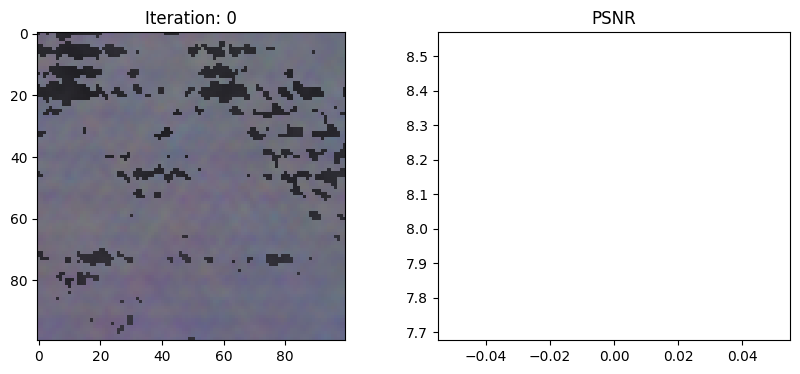

25 0.8858450412750244 secs per iter


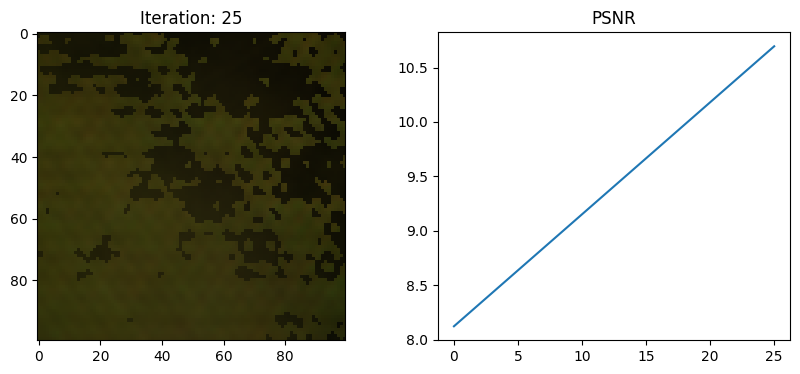

50 0.7097867965698242 secs per iter


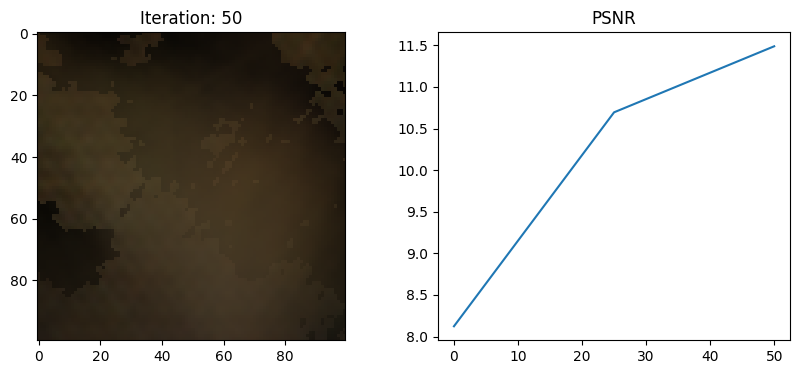

75 0.7137071514129638 secs per iter


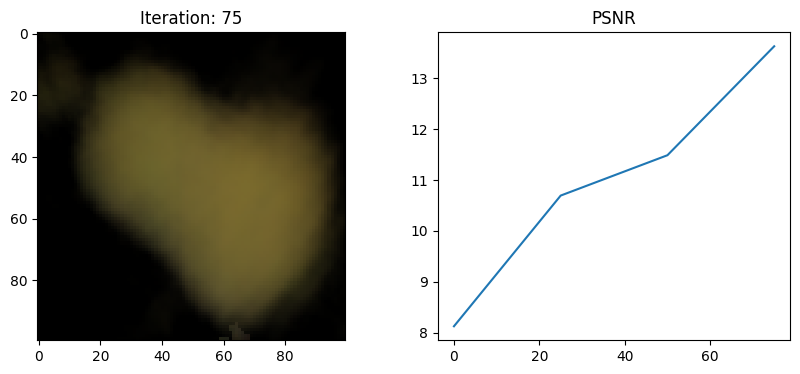

100 0.6989155483245849 secs per iter


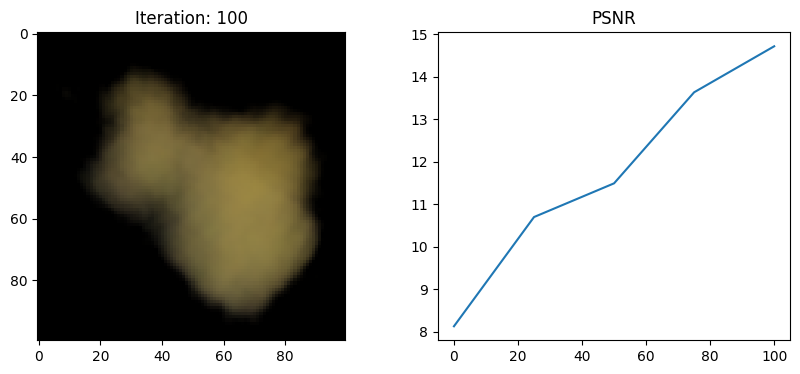

125 0.7993667507171631 secs per iter


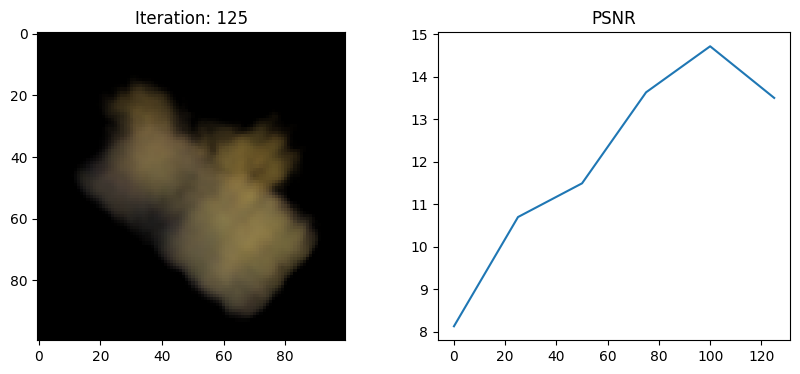

150 0.7184705638885498 secs per iter


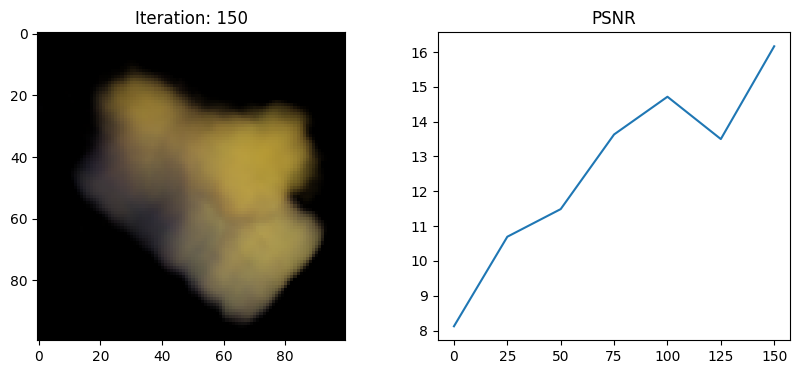

175 0.7320432853698731 secs per iter


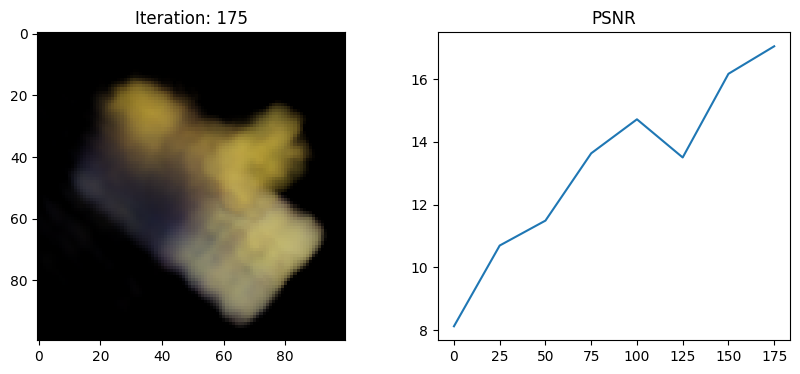

200 0.7091620254516602 secs per iter


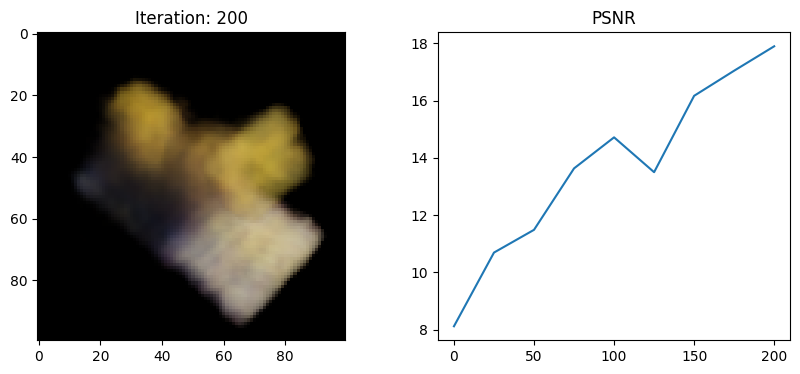

225 0.7383327484130859 secs per iter


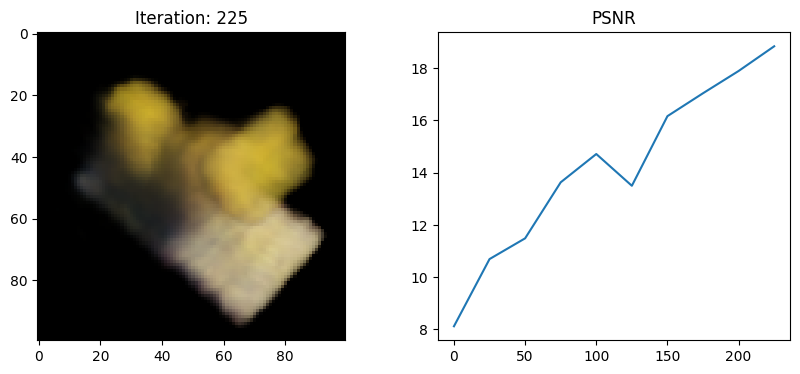

250 0.7276562881469727 secs per iter


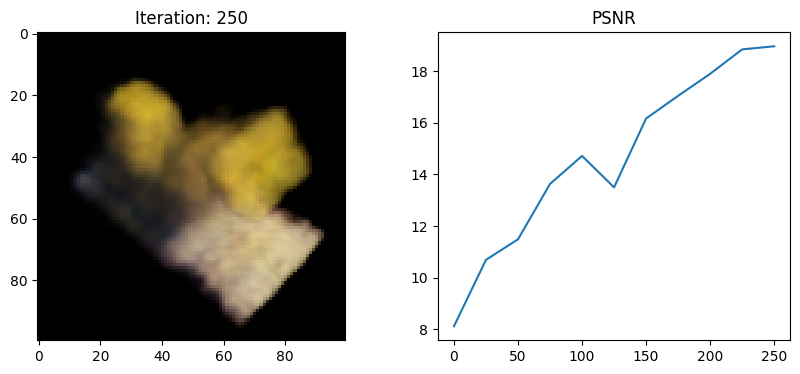

275 0.7600119590759278 secs per iter


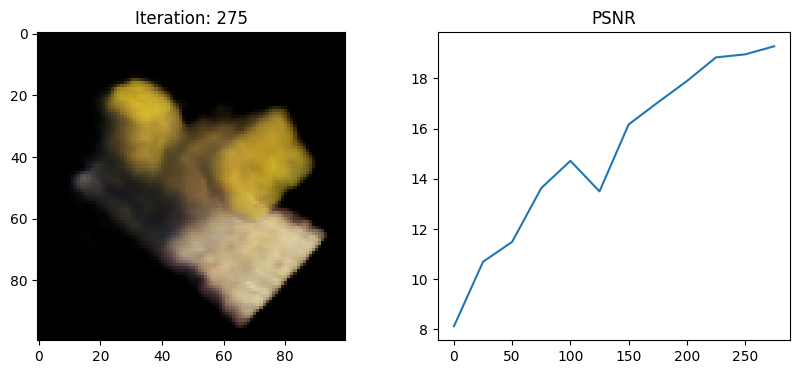

300 0.758262882232666 secs per iter


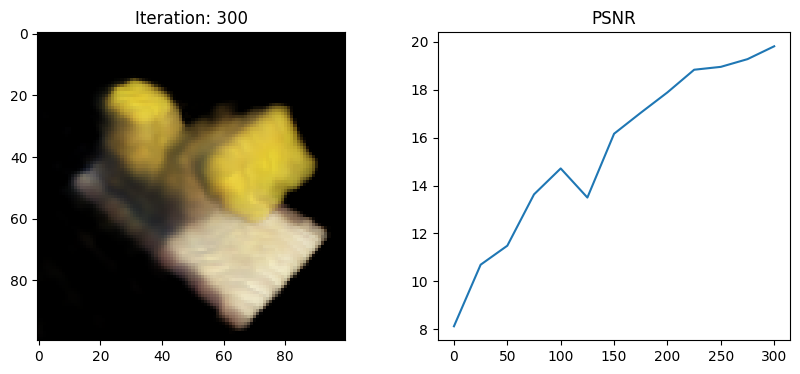

325 0.7722690391540528 secs per iter


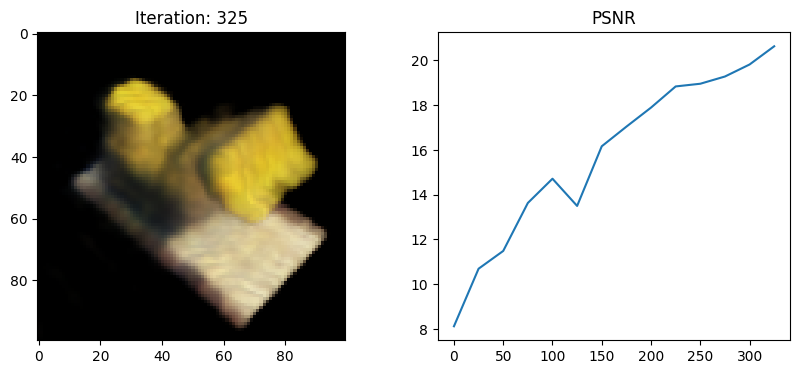

350 0.7377078723907471 secs per iter


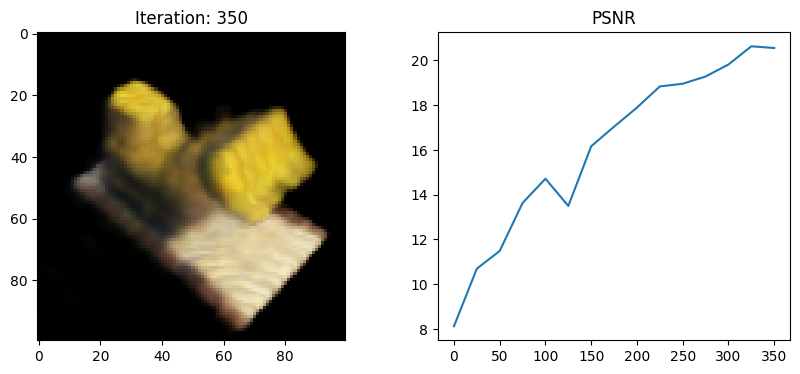

375 0.7572955799102783 secs per iter


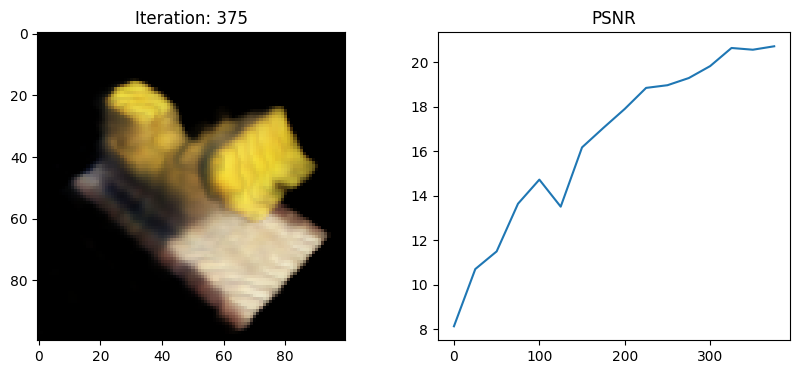

400 0.7486847972869873 secs per iter


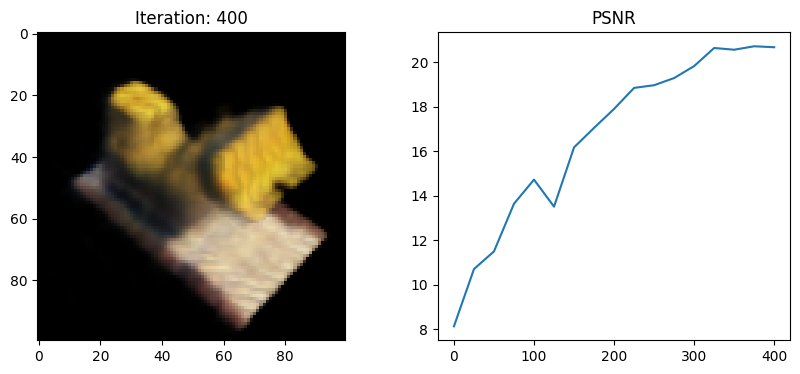

425 0.759107255935669 secs per iter


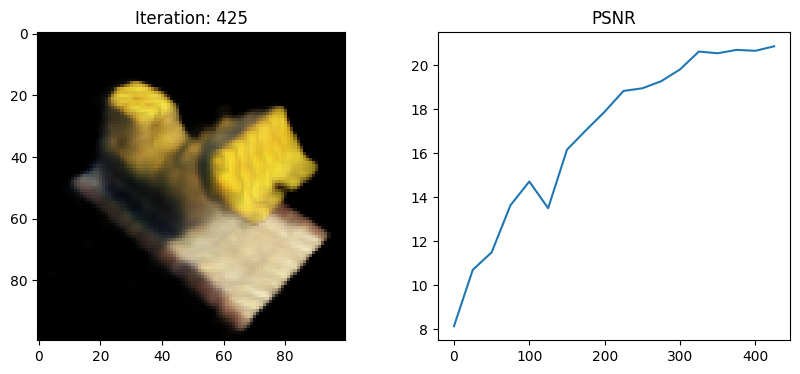

450 0.7429666328430176 secs per iter


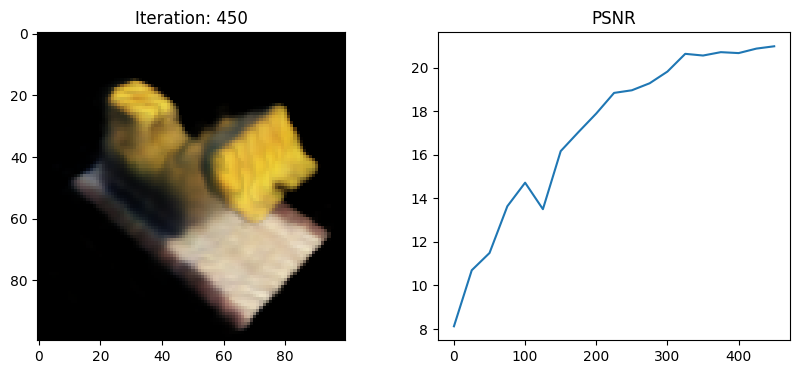

475 0.7606047344207764 secs per iter


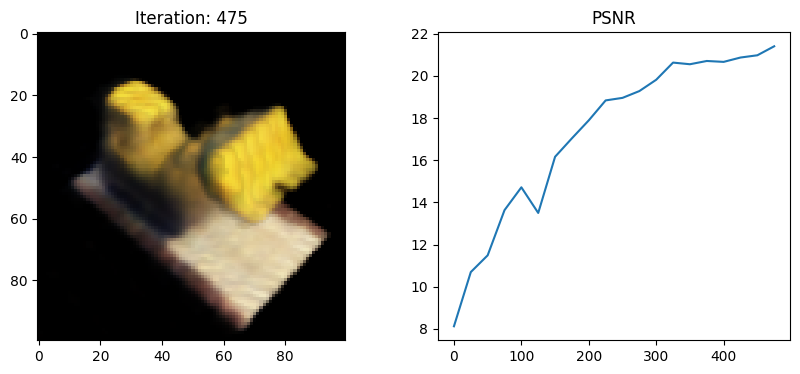

500 0.7498772525787354 secs per iter


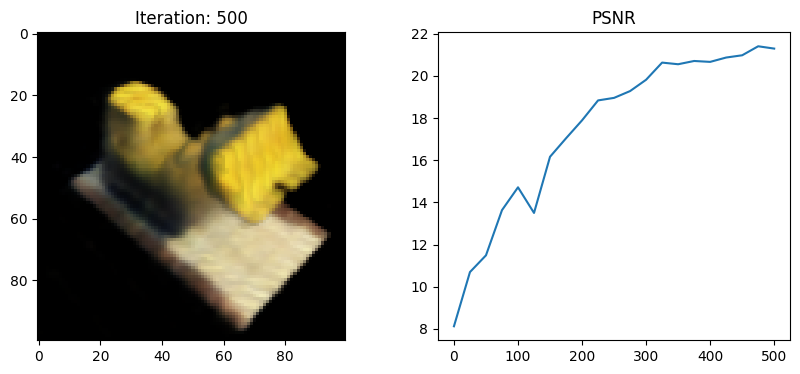

525 0.7632582092285156 secs per iter


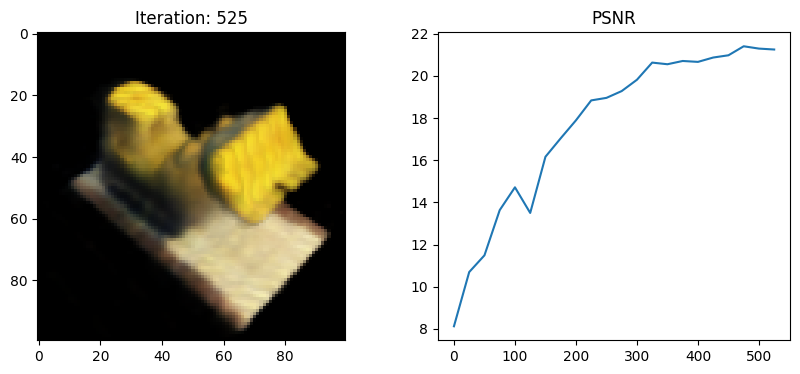

550 0.7611601448059082 secs per iter


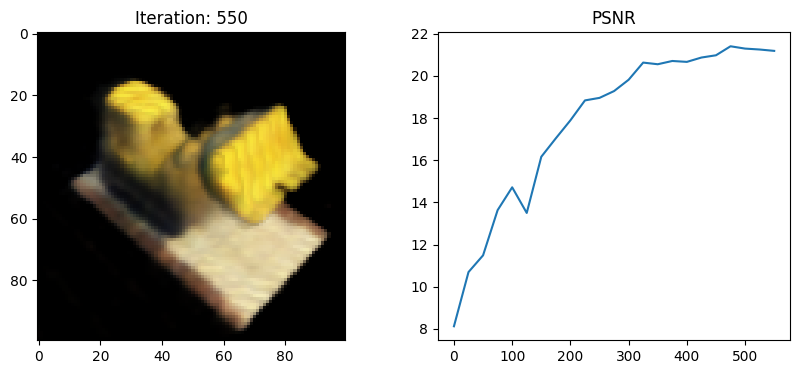

575 0.763664789199829 secs per iter


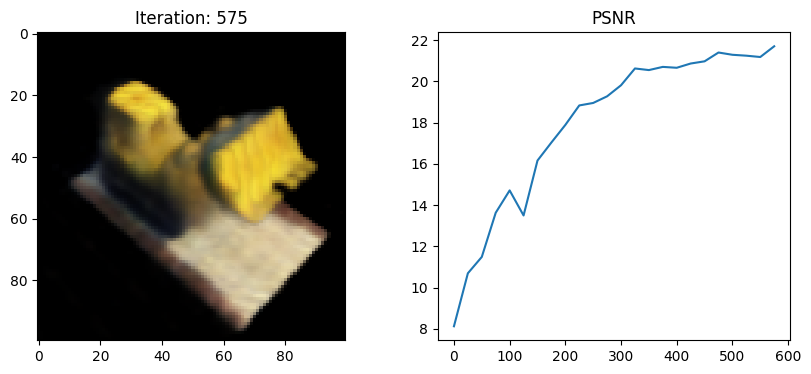

600 0.7705477809906006 secs per iter


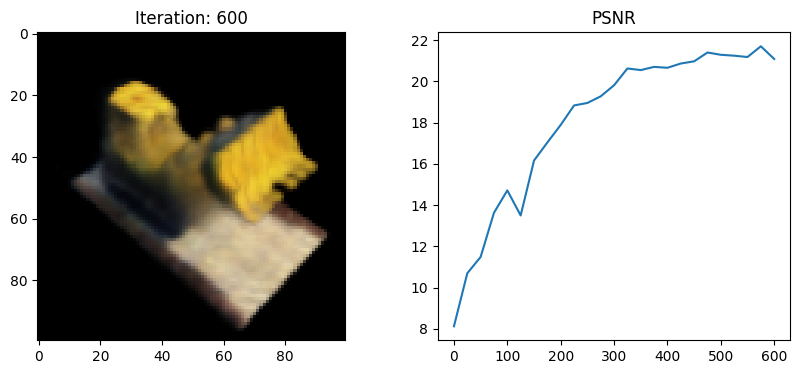

625 0.7464618873596192 secs per iter


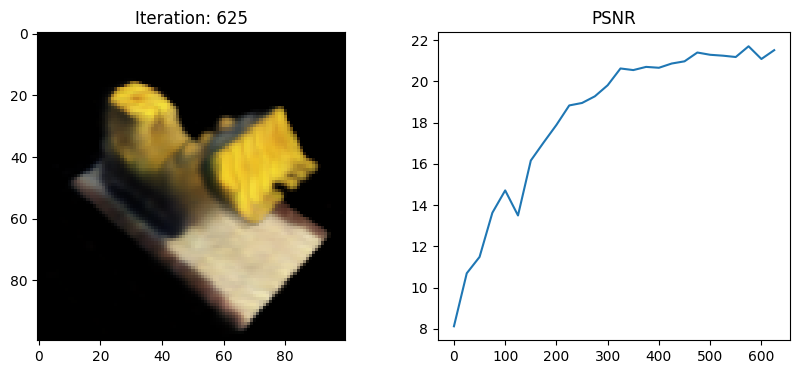

650 0.7582424736022949 secs per iter


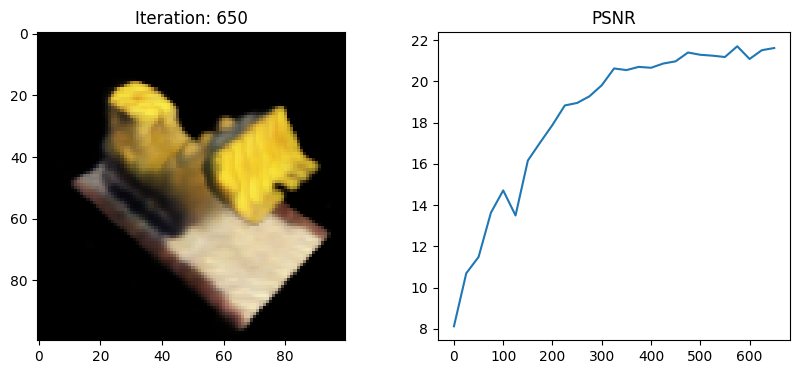

675 0.7462611865997314 secs per iter


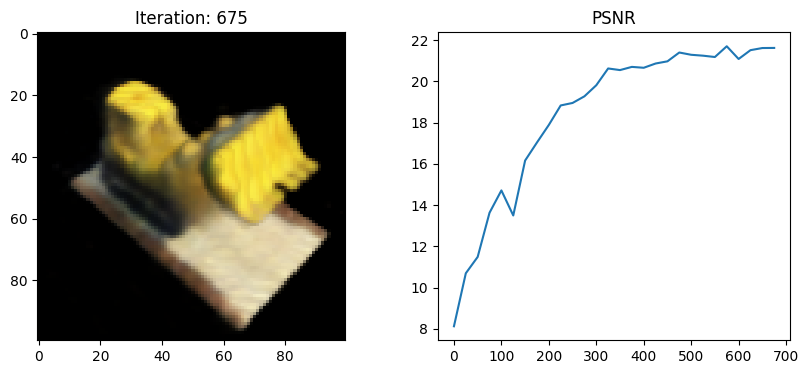

700 0.7595951652526856 secs per iter


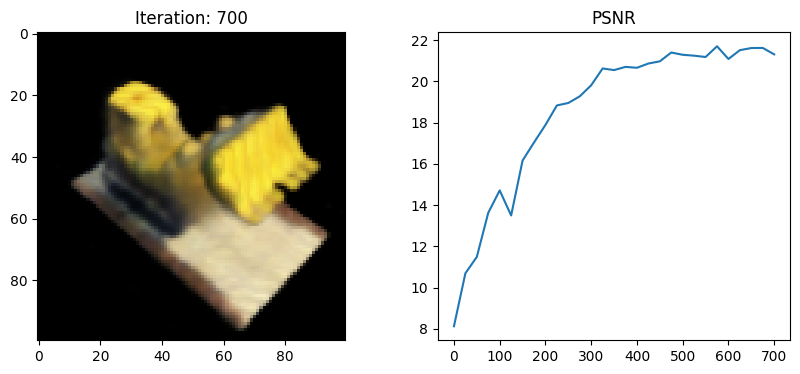

725 0.7488868999481201 secs per iter


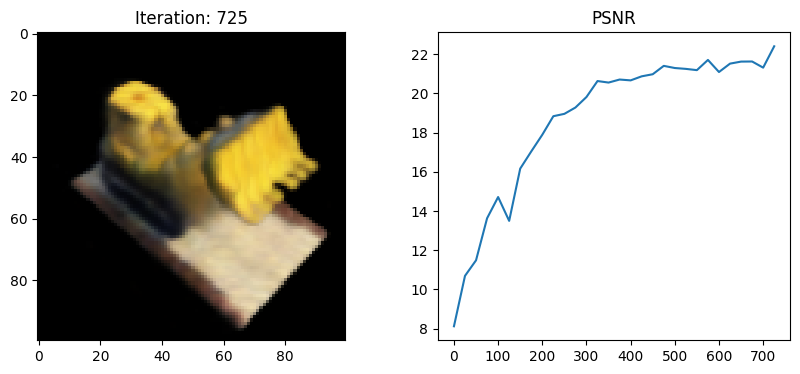

750 0.7613845252990723 secs per iter


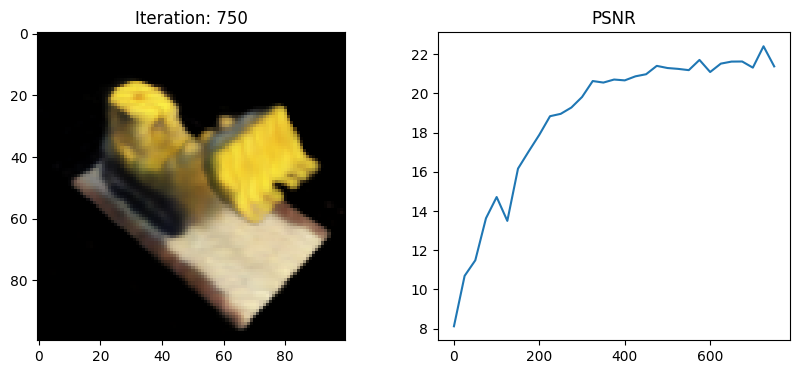

775 0.7457385349273682 secs per iter


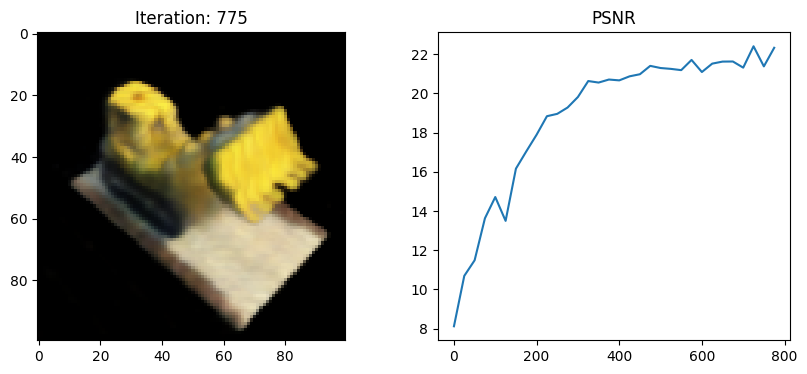

800 0.7585053539276123 secs per iter


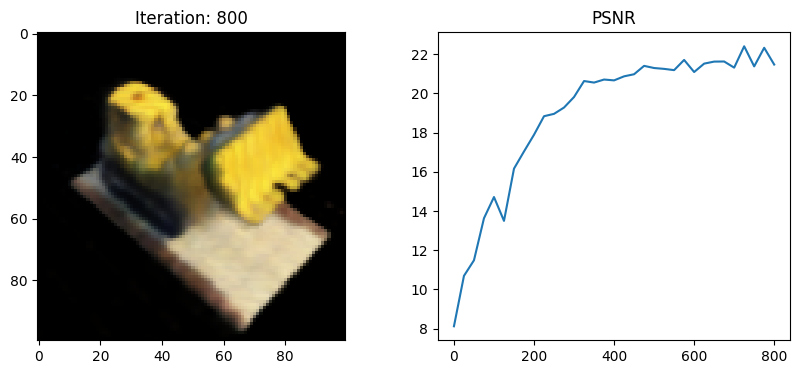

825 0.7453143692016602 secs per iter


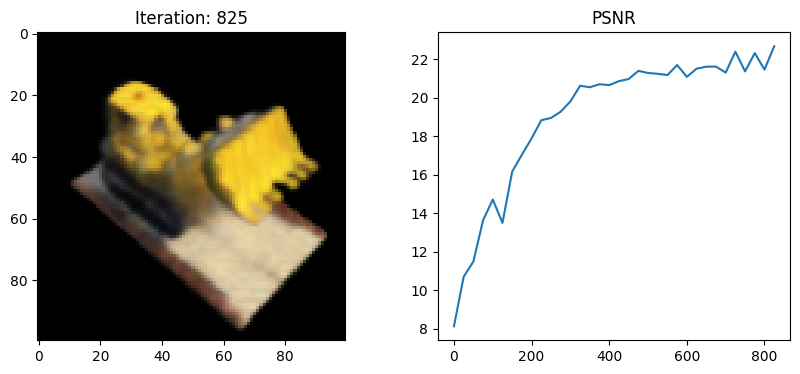

850 0.7630069637298584 secs per iter


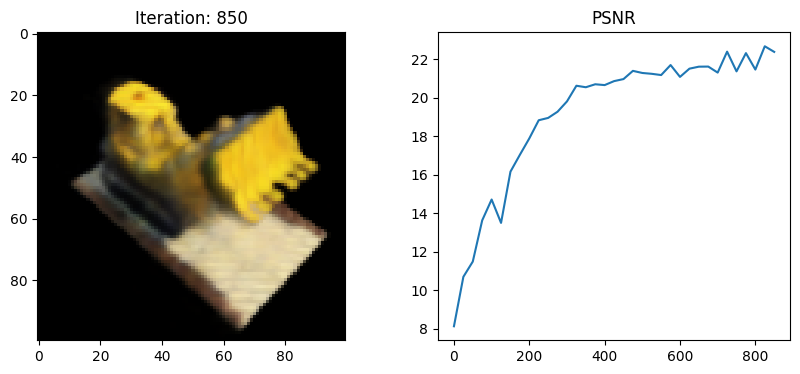

875 0.7587513732910156 secs per iter


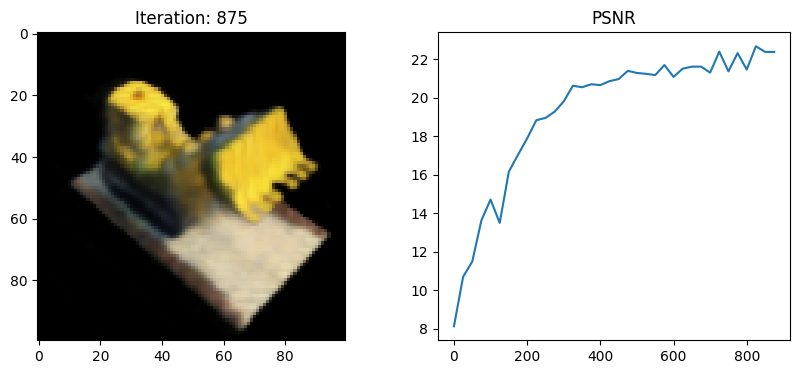

900 0.7653186511993408 secs per iter


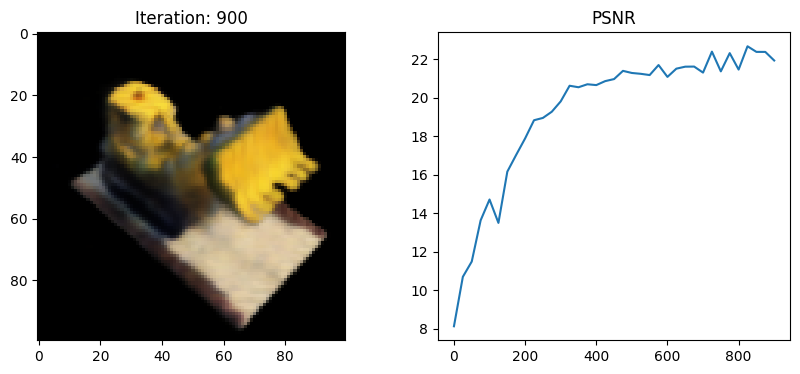

925 0.7642172527313232 secs per iter


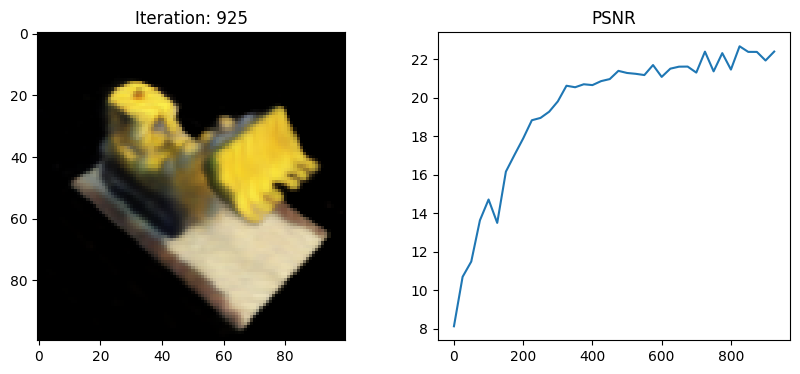

950 0.7554611873626709 secs per iter


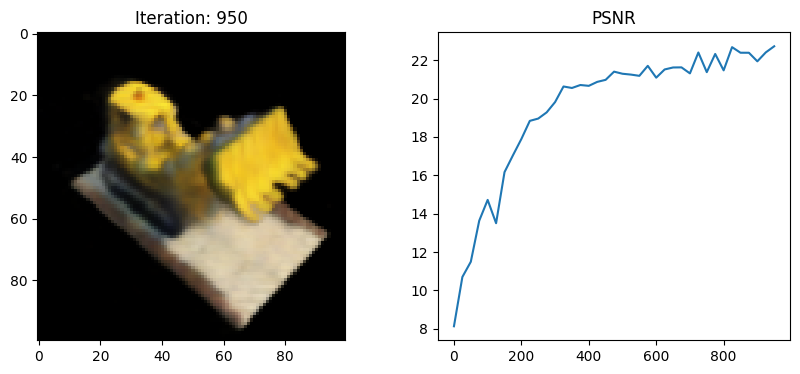

975 0.7626711750030517 secs per iter


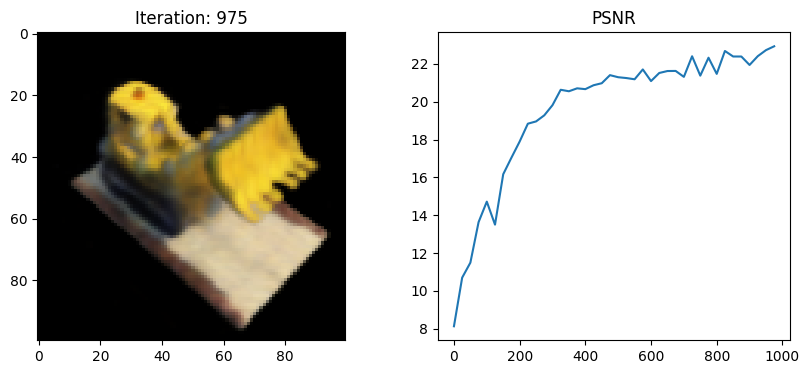

1000 0.7520271301269531 secs per iter


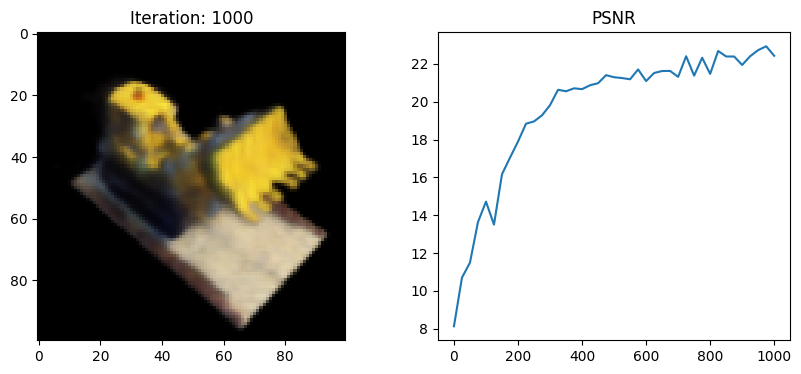

Done


In [6]:
model = init_model()
optimizer = tf.keras.optimizers.Adam(5e-4)

N_samples = 64
N_iters = 1000
psnrs = []
iternums = []
i_plot = 25

import time
t = time.time()
for i in range(N_iters+1):

    img_i = np.random.randint(images.shape[0])
    target = images[img_i]
    pose = poses[img_i]
    rays_o, rays_d = get_rays(H, W, focal, pose)
    with tf.GradientTape() as tape:
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples, rand=True)
        loss = tf.reduce_mean(tf.square(rgb - target))
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if i%i_plot==0:
        print(i, (time.time() - t) / i_plot, 'secs per iter')
        t = time.time()

        # Render the holdout view for logging
        rays_o, rays_d = get_rays(H, W, focal, testpose)
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
        loss = tf.reduce_mean(tf.square(rgb - testimg))
        psnr = -10. * tf.math.log(loss) / tf.math.log(10.)

        psnrs.append(psnr.numpy())
        iternums.append(i)

        plt.figure(figsize=(10,4))
        plt.subplot(121)
        plt.imshow(rgb)
        plt.title(f'Iteration: {i}')
        plt.subplot(122)
        plt.plot(iternums, psnrs)
        plt.title('PSNR')
        plt.show()

print('Done')

### **Optimizing the NeRF Model (Training)**

This section is where the neural network learns to represent the 3D scene. It's an iterative process of showing the network an image, letting it guess, and then correcting its guesses.

*   **`model = init_model()`:** Initializes a fresh neural network based on the architecture defined earlier.
*   **`optimizer = tf.keras.optimizers.Adam(...)`:** Sets up an "optimizer," which is an algorithm that adjusts the network's internal parameters (weights) to minimize errors. Adam is a popular choice.
*   **Training Loop (`for i in range(N_iters+1):`)**:
    1.  **Pick a Random Image:** In each iteration, the code randomly selects one of the training images and its corresponding camera `pose`.
    2.  **Generate Rays:** It uses `get_rays` to calculate the rays for this chosen image.
    3.  **Forward Pass:** The `render_rays` function simulates what the scene would look like from that `pose`, producing `rgb` (predicted image), `depth`, and `acc`.
    4.  **Calculate Loss:** The `loss` is calculated as the `tf.reduce_mean(tf.square(rgb - target))`. This is the "Mean Squared Error" – it measures how different the `predicted image (rgb)` is from the `actual image (target)`. The goal of training is to make this loss as small as possible.
    5.  **Backward Pass (Backpropagation):** `tape.gradient(loss, model.trainable_variables)` calculates how much each parameter in the network contributed to the `loss`. `optimizer.apply_gradients` then uses these gradients to slightly adjust the network's parameters in the direction that would reduce the loss.
    6.  **Logging and Visualization:** Every `i_plot` iterations:
        *   It renders the `testimg` (the unseen image we set aside earlier) using the *current* state of the trained model.
        *   It calculates the **PSNR (Peak Signal-to-Noise Ratio)**, which is a common metric to evaluate image quality. Higher PSNR means a better-quality image and a more accurate reconstruction of the scene.
        *   It plots the rendered test image and a graph showing how the PSNR improves over time. This helps us see if the model is learning correctly.

# Interactive Visualization

In [7]:
%matplotlib inline
from ipywidgets import interactive, widgets


trans_t = lambda t : tf.convert_to_tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=tf.float32)

rot_phi = lambda phi : tf.convert_to_tensor([
    [1,0,0,0],
    [0,tf.cos(phi),-tf.sin(phi),0],
    [0,tf.sin(phi), tf.cos(phi),0],
    [0,0,0,1],
], dtype=tf.float32)

rot_theta = lambda th : tf.convert_to_tensor([
    [tf.cos(th),0,-tf.sin(th),0],
    [0,1,0,0],
    [tf.sin(th),0, tf.cos(th),0],
    [0,0,0,1],
], dtype=tf.float32)


def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    c2w = np.array([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ c2w
    return c2w


def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    img = np.clip(rgb,0,1)

    plt.figure(2, figsize=(20,6))
    plt.imshow(img)
    plt.show()


sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0] : sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

### **Interactive Visualization**

This section allows you to explore the learned 3D scene interactively using sliders. It lets you change the camera's position and orientation to render new views in real-time.

*   **Transformation Functions (`trans_t`, `rot_phi`, `rot_theta`):** These are helper functions that create matrices to move (`trans_t`) and rotate (`rot_phi`, `rot_theta`) the camera in 3D space. They are fundamental to defining where the camera is looking.
*   **`pose_spherical(theta, phi, radius)`:** This combines the transformation functions to calculate a camera pose that moves along a sphere around the object. You can control its horizontal angle (`theta`), vertical angle (`phi`), and distance from the center (`radius`).
*   **`f(**kwargs)`:** This function takes the camera parameters from the sliders, calculates the `c2w` (camera-to-world) matrix, generates rays, renders the scene using the *trained* `model`, and then displays the resulting image.
*   **`interactive(...)`:** This `ipywidgets` feature connects the `f` function to the sliders (`theta`, `phi`, `radius`). When you drag a slider, it updates the camera parameters, and the `f` function automatically re-renders and displays the new view, giving you an interactive experience.

# Render 360 Video

In [8]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    frames.append((255*np.clip(rgb,0,1)).astype(np.uint8))

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

/tmp/ipykernel_1766/3499152080.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):


  0%|          | 0/120 [00:00<?, ?it/s]

In [9]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

### **Render 360 Video**

This final section takes the interactive visualization concept a step further by automatically generating a sequence of images around the object and stitching them into a video.

*   **Looping through Angles:** The code uses `tqdm` (for a progress bar) to loop through a range of `theta` values from 0 to 360 degrees, simulating a camera rotating around the object.
*   **Generating Frames:** For each `theta` value, it calculates a camera pose using `pose_spherical`, renders the scene with the trained `model`, and saves the resulting image as a frame in a list.
*   **Creating the Video:** `imageio.mimwrite(f, frames, fps=30, quality=7)` takes all the collected frames and combines them into an MP4 video file named `video.mp4` at 30 frames per second.
*   **Displaying the Video:** The last cell reads the generated `video.mp4` file, encodes it in `base64`, and then embeds it directly into the Colab notebook using HTML, allowing you to watch the generated 360-degree view of the bulldozer right there.